<a href="https://colab.research.google.com/github/ujwala0/Analysis/blob/main/E-commerce%20Marketplace%20Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [35]:
from google.colab import files

uploaded = files.upload()

Saving Document from singhlink4.xlsx to Document from singhlink4 (1).xlsx


In [36]:
import pandas as pd

filename = list(uploaded.keys())[0]

excel_file = pd.ExcelFile(filename)

print("Sheets available:")
print(excel_file.sheet_names)

Sheets available:
['orders', 'order_items', 'order_payments', 'order_reviews', 'customers', 'products', 'sellers', 'geolocation', 'category_translation']


In [37]:
# 1. Load the 8 manageable datasets
orders = pd.read_excel(filename, sheet_name='orders')
items = pd.read_excel(filename, sheet_name='order_items')
payments = pd.read_excel(filename, sheet_name='order_payments')
reviews = pd.read_excel(filename, sheet_name='order_reviews')
customers = pd.read_excel(filename, sheet_name='customers')
products = pd.read_excel(filename, sheet_name='products')
sellers = pd.read_excel(filename, sheet_name='sellers')
translation = pd.read_excel(filename, sheet_name='category_translation')

print("8 datasets loaded successfully!\n")

8 datasets loaded successfully!



In [38]:
# 2. Dataset sizes
datasets = {
    'orders': orders,
    'order_items': items,
    'order_payments': payments,
    'order_reviews': reviews,
    'customers': customers,
    'products': products,
    'sellers': sellers,
    'category_translation': translation
}

print("DATASET SIZES")
print("=" * 50)

for name, data in datasets.items():
    print(f"{name:20} → {data.shape[0]:,} rows × {data.shape[1]} columns")


DATASET SIZES
orders               → 99,441 rows × 8 columns
order_items          → 112,650 rows × 6 columns
order_payments       → 103,886 rows × 5 columns
order_reviews        → 100,000 rows × 7 columns
customers            → 99,441 rows × 5 columns
products             → 32,951 rows × 9 columns
sellers              → 3,095 rows × 4 columns
category_translation → 71 rows × 2 columns


In [39]:
# 3. Order statuses
print("\nORDER STATUS")
print("=" * 50)
print(orders['order_status'].value_counts())

# 4. Missing values in orders
print("\nMISSING VALUES IN ORDERS")
print("=" * 50)
print(orders.isnull().sum())


ORDER STATUS
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

MISSING VALUES IN ORDERS
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64


In [41]:
# ============================================
# DATA CLEANING
# ============================================

# 1. Make copies so the original data stays safe
orders_clean = orders.copy()
items_clean = items.copy()
payments_clean = payments.copy()
reviews_clean = reviews.copy()
customers_clean = customers.copy()
products_clean = products.copy()
sellers_clean = sellers.copy()
translation_clean = translation.copy()

# 2. Convert date columns to proper datetime format

date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_columns:
    orders_clean[col] = pd.to_datetime(
        orders_clean[col],
        errors='coerce'
    )

reviews_clean['review_creation_date'] = pd.to_datetime(
    reviews_clean['review_creation_date'],
    errors='coerce'
)

reviews_clean['review_answer_timestamp'] = pd.to_datetime(
    reviews_clean['review_answer_timestamp'],
    errors='coerce'
)

# 3. Check duplicate rows

print("DUPLICATE ROWS")
print("=" * 50)

print("Orders:", orders_clean.duplicated().sum())
print("Items:", items_clean.duplicated().sum())
print("Payments:", payments_clean.duplicated().sum())
print("Reviews:", reviews_clean.duplicated().sum())
print("Customers:", customers_clean.duplicated().sum())
print("Products:", products_clean.duplicated().sum())
print("Sellers:", sellers_clean.duplicated().sum())

# 4. Check order statuses

print("\nORDER STATUS")
print("=" * 50)
print(orders_clean['order_status'].value_counts())

# 5. Create delivered-orders dataset

delivered_orders = orders_clean[
    orders_clean['order_status'] == 'delivered'
].copy()

print("\nDELIVERED ORDERS")
print("=" * 50)
print("Delivered orders:", len(delivered_orders))
print("Total orders:", len(orders_clean))
print(
    "Delivery rate:",
    round(len(delivered_orders) / len(orders_clean) * 100, 2),
    "%"
)

# 6. Calculate delivery timing

delivered_orders['actual_delivery_days'] = (
    delivered_orders['order_delivered_customer_date']
    - delivered_orders['order_purchase_timestamp']
).dt.total_seconds() / (24 * 60 * 60)

delivered_orders['delivery_difference_days'] = (
    delivered_orders['order_delivered_customer_date']
    - delivered_orders['order_estimated_delivery_date']
).dt.total_seconds() / (24 * 60 * 60)

# 7. Create early/on-time/late category

delivered_orders['delivery_status'] = delivered_orders[
    'delivery_difference_days'
].apply(
    lambda x:
        'Early' if x < 0
        else 'On Time' if x == 0
        else 'Late'
)

print("\nDELIVERY STATUS")
print("=" * 50)
print(delivered_orders['delivery_status'].value_counts())

# 8. Basic delivery statistics

print("\nDELIVERY STATISTICS")
print("=" * 50)
print(
    delivered_orders[
        ['actual_delivery_days', 'delivery_difference_days']
    ].describe()
)

DUPLICATE ROWS
Orders: 0
Items: 0
Payments: 0
Reviews: 0
Customers: 0
Products: 0
Sellers: 0

ORDER STATUS
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

DELIVERED ORDERS
Delivered orders: 96478
Total orders: 99441
Delivery rate: 97.02 %

DELIVERY STATUS
delivery_status
Early    88644
Late      7834
Name: count, dtype: int64

DELIVERY STATISTICS
       actual_delivery_days  delivery_difference_days
count          96470.000000              96470.000000
mean              12.558217                -11.178126
std                9.546156                 10.184354
min                0.533414               -146.016123
25%                6.766204                -16.244065
50%               10.217477                -11.948102
75%               15.720182                 -6.389815
max              209.628611                188.975081


In [42]:
# ============================================
# DELIVERY PERFORMANCE vs CUSTOMER SATISFACTION
# ============================================

# Select review information
review_data = reviews_clean[
    ['order_id', 'review_score']
].copy()

# Join reviews to delivered orders
delivery_reviews = delivered_orders.merge(
    review_data,
    on='order_id',
    how='left'
)

print("Total delivered orders:", len(delivery_reviews))
print("Orders with review scores:", delivery_reviews['review_score'].notna().sum())

# Average review score by delivery status
review_by_delivery = (
    delivery_reviews
    .groupby('delivery_status')['review_score']
    .agg(['count', 'mean'])
    .round(2)
)

print("\nAVERAGE REVIEW SCORE BY DELIVERY STATUS")
print("=" * 55)
print(review_by_delivery)

# Review score distribution by delivery status
review_distribution = pd.crosstab(
    delivery_reviews['delivery_status'],
    delivery_reviews['review_score'],
    normalize='index'
).round(3) * 100

print("\nREVIEW SCORE % BY DELIVERY STATUS")
print("=" * 55)
print(review_distribution)

Total delivered orders: 97015
Orders with review scores: 97015

AVERAGE REVIEW SCORE BY DELIVERY STATUS
                 count  mean
delivery_status             
Early            89142  4.28
Late              7873  2.55

REVIEW SCORE % BY DELIVERY STATUS
review_score        1    2     3     4     5
delivery_status                             
Early             6.8  2.7   8.0  20.3  62.2
Late             46.6  7.9  11.3  12.2  21.9


In [43]:
# ============================================
# ORDER-LEVEL ITEM SUMMARY
# ============================================

items_order = (
    items_clean
    .groupby('order_id')
    .agg(
        total_price=('price', 'sum'),
        total_freight=('freight_value', 'sum'),
        item_count=('order_item_id', 'count'),
        unique_products=('product_id', 'nunique'),
        unique_sellers=('seller_id', 'nunique')
    )
    .reset_index()
)

print("ITEM SUMMARY")
print("=" * 50)
print(items_order.head())
print("\nNumber of orders with items:", len(items_order))

# ============================================
# ORDER-LEVEL PAYMENT SUMMARY
# ============================================

payments_order = (
    payments_clean
    .groupby('order_id')
    .agg(
        total_payment_value=('payment_value', 'sum'),
        payment_records=('payment_sequential', 'count'),
        max_installments=('payment_installments', 'max')
    )
    .reset_index()
)

print("PAYMENT SUMMARY")
print("=" * 50)
print(payments_order.head())
print("\nNumber of orders with payments:", len(payments_order))

ITEM SUMMARY
                           order_id  total_price  total_freight  item_count  \
0  00010242fe8c5a6d1ba2dd792cb16214        58.90          13.29           1   
1  00018f77f2f0320c557190d7a144bdd3       239.90          19.93           1   
2  000229ec398224ef6ca0657da4fc703e       199.00          17.87           1   
3  00024acbcdf0a6daa1e931b038114c75        12.99          12.79           1   
4  00042b26cf59d7ce69dfabb4e55b4fd9       199.90          18.14           1   

   unique_products  unique_sellers  
0                1               1  
1                1               1  
2                1               1  
3                1               1  
4                1               1  

Number of orders with items: 98666
PAYMENT SUMMARY
                           order_id  total_payment_value  payment_records  \
0  00010242fe8c5a6d1ba2dd792cb16214                72.19                1   
1  00018f77f2f0320c557190d7a144bdd3               259.83                1   
2  0002

In [44]:
# ============================================
# BUILD MASTER ORDER-LEVEL DATASET
# ============================================

# Start with all orders
master = orders_clean.copy()

# Add item-level summary
master = master.merge(
    items_order,
    on='order_id',
    how='left'
)

# Add payment-level summary
master = master.merge(
    payments_order,
    on='order_id',
    how='left'
)

print("MASTER DATASET CREATED")
print("=" * 50)
print("Rows:", len(master))
print("Columns:", len(master.columns))

print("\nColumns:")
print(master.columns.tolist())

print("\nFirst 5 rows:")
display(master.head())




# ============================================
# ADD CUSTOMER INFORMATION
# ============================================

master = master.merge(
    customers_clean[
        [
            'customer_id',
            'customer_unique_id',
            'customer_zip_code_prefix',
            'customer_city',
            'customer_state'
        ]
    ],
    on='customer_id',
    how='left'
)

# Add review score
master = master.merge(
    reviews_clean[
        ['order_id', 'review_score']
    ],
    on='order_id',
    how='left'
)

print("After adding customers and reviews:")
print("Rows:", len(master))
print("Columns:", len(master.columns))

display(master.head())



# ============================================
# MASTER DATASET QUALITY CHECK
# ============================================

print("MASTER DATASET")
print("=" * 50)

print("Rows:", len(master))
print("Columns:", len(master.columns))

print("\nMissing values:")
print(master.isnull().sum().sort_values(ascending=False).head(15))

MASTER DATASET CREATED
Rows: 99441
Columns: 16

Columns:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'total_price', 'total_freight', 'item_count', 'unique_products', 'unique_sellers', 'total_payment_value', 'payment_records', 'max_installments']

First 5 rows:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,total_price,total_freight,item_count,unique_products,unique_sellers,total_payment_value,payment_records,max_installments
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,29.99,8.72,1.0,1.0,1.0,38.71,3.0,1.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,118.70,22.76,1.0,1.0,1.0,141.46,1.0,1.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,159.90,19.22,1.0,1.0,1.0,179.12,1.0,3.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,45.00,27.20,1.0,1.0,1.0,72.20,1.0,1.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,19.90,8.72,1.0,1.0,1.0,28.62,1.0,1.0


After adding customers and reviews:
Rows: 100000
Columns: 21


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,total_price,total_freight,...,unique_products,unique_sellers,total_payment_value,payment_records,max_installments,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,29.99,8.72,...,1.0,1.0,38.71,3.0,1.0,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,4
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,118.70,22.76,...,1.0,1.0,141.46,1.0,1.0,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,4
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,159.90,19.22,...,1.0,1.0,179.12,1.0,3.0,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,5
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,45.00,27.20,...,1.0,1.0,72.20,1.0,1.0,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,5
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,19.90,8.72,...,1.0,1.0,28.62,1.0,1.0,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,5


MASTER DATASET
Rows: 100000
Columns: 21

Missing values:
order_delivered_customer_date    2987
order_delivered_carrier_date     1793
total_price                       778
total_freight                     778
unique_products                   778
unique_sellers                    778
item_count                        778
order_approved_at                 161
total_payment_value                 1
max_installments                    1
payment_records                     1
customer_id                         0
order_id                            0
order_purchase_timestamp            0
order_status                        0
dtype: int64


In [45]:
# ============================================
# FIX REVIEW DUPLICATION + REBUILD MASTER
# ============================================

# Check how many reviews each order has
review_counts = reviews_clean.groupby('order_id').size()

print("Orders with multiple review records:",
      (review_counts > 1).sum())

# Keep ONE review score per order
# If multiple reviews exist, use the average score
reviews_order = (
    reviews_clean
    .groupby('order_id', as_index=False)
    .agg(
        review_score=('review_score', 'mean')
    )
)

# Start again from the original orders table
master = orders_clean.copy()

# Add item summary
master = master.merge(
    items_order,
    on='order_id',
    how='left'
)

# Add payment summary
master = master.merge(
    payments_order,
    on='order_id',
    how='left'
)

# Add customer information
master = master.merge(
    customers_clean[
        [
            'customer_id',
            'customer_unique_id',
            'customer_zip_code_prefix',
            'customer_city',
            'customer_state'
        ]
    ],
    on='customer_id',
    how='left'
)

# Add ONE review record per order
master = master.merge(
    reviews_order,
    on='order_id',
    how='left'
)

print("\nMASTER DATASET AFTER FIX")
print("=" * 50)
print("Rows:", len(master))
print("Columns:", len(master.columns))

# Verify order_id is unique
print("Unique order IDs:", master['order_id'].nunique())

print("\nDuplicate order IDs:",
      master['order_id'].duplicated().sum())

print("\nMissing values:")
print(master.isnull().sum().sort_values(ascending=False).head(15))

Orders with multiple review records: 555

MASTER DATASET AFTER FIX
Rows: 99441
Columns: 21
Unique order IDs: 99441

Duplicate order IDs: 0

Missing values:
order_delivered_customer_date    2965
order_delivered_carrier_date     1783
total_price                       775
total_freight                     775
unique_products                   775
unique_sellers                    775
item_count                        775
order_approved_at                 160
total_payment_value                 1
max_installments                    1
payment_records                     1
customer_id                         0
order_id                            0
order_purchase_timestamp            0
order_status                        0
dtype: int64


In [46]:
# ============================================
# MARKETPLACE PERFORMANCE OVER TIME
# ============================================

# Create a month column
master['order_month'] = (
    master['order_purchase_timestamp']
    .dt.to_period('M')
    .astype(str)
)

# Monthly marketplace performance
monthly_performance = (
    master
    .groupby('order_month')
    .agg(
        orders=('order_id', 'nunique'),
        revenue=('total_price', 'sum'),
        average_review=('review_score', 'mean')
    )
    .reset_index()
)

# Average order value
monthly_performance['average_order_value'] = (
    monthly_performance['revenue'] /
    monthly_performance['orders']
)

# Display results
print("MONTHLY MARKETPLACE PERFORMANCE")
print("=" * 70)

display(monthly_performance.round(2))

MONTHLY MARKETPLACE PERFORMANCE


,order_month,orders,revenue,average_review,average_order_value
0,2016-09,4,267.36,1.00,66.84
1,2016-10,324,49507.66,3.52,152.80
2,2016-12,1,10.90,5.00,10.90
3,2017-01,800,120312.87,4.05,150.39
4,2017-02,1780,247303.02,4.00,138.93
5,2017-03,2682,374344.30,4.06,139.58
6,2017-04,2404,359927.23,4.03,149.72
7,2017-05,3700,506071.14,4.12,136.78
8,2017-06,3245,433038.60,4.13,133.45
9,2017-07,4026,498031.48,4.16,123.70


In [ ]:
# ============================================
# MONTHLY ORDER VOLUME
# ============================================

import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_performance['order_month'],
    monthly_performance['orders'],
    marker='o'
)

plt.title('Monthly Order Volume')
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

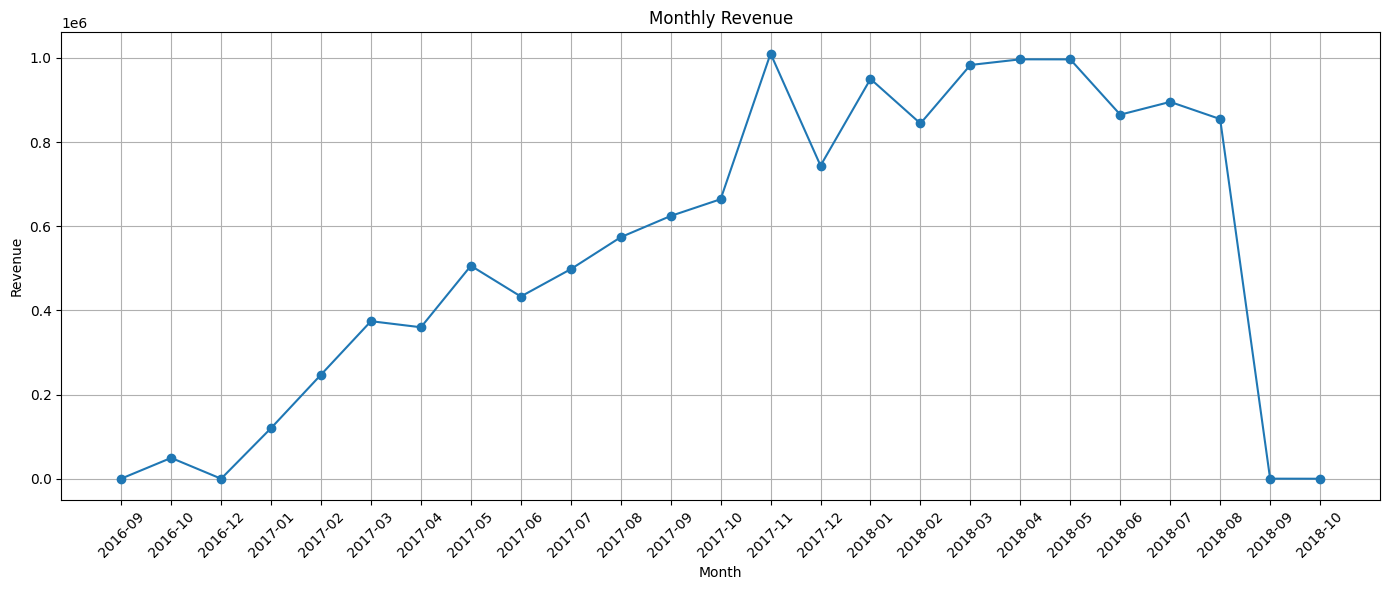

In [47]:
# ============================================
# MONTHLY REVENUE
# ============================================

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_performance['order_month'],
    monthly_performance['revenue'],
    marker='o'
)

plt.title('Monthly Revenue')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

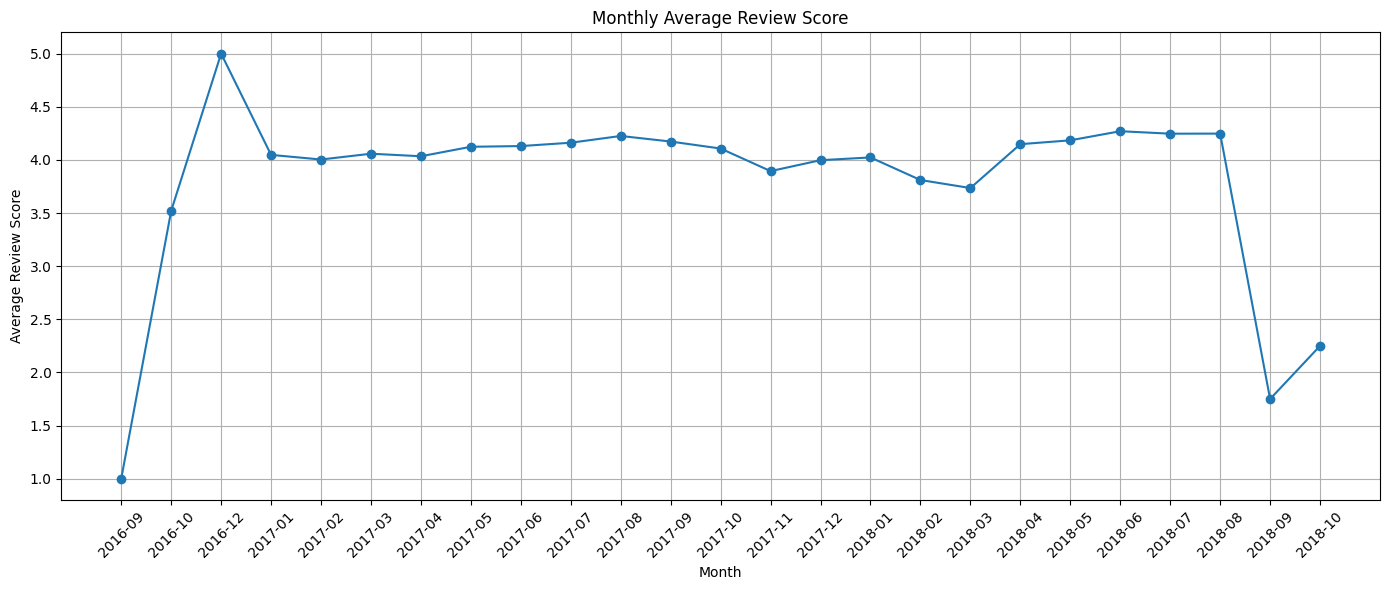

In [48]:
# ============================================
# MONTHLY AVERAGE REVIEW SCORE
# ============================================

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_performance['order_month'],
    monthly_performance['average_review'],
    marker='o'
)

plt.title('Monthly Average Review Score')
plt.xlabel('Month')
plt.ylabel('Average Review Score')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [49]:
# ============================================
# SUMMARIZE MARKETPLACE TREND
# ============================================

print("MARKETPLACE TREND SUMMARY")
print("=" * 60)

print("\nFirst 5 months:")
display(monthly_performance.head().round(2))

print("\nLast 5 months:")
display(monthly_performance.tail().round(2))

print("\nOVERALL METRICS")
print("=" * 60)

print("Total orders:",
      master['order_id'].nunique())

print("Total item revenue:",
      round(master['total_price'].sum(), 2))

print("Average order value:",
      round(master['total_price'].mean(), 2))

print("Overall average review score:",
      round(master['review_score'].mean(), 2))

print("\nBest month by orders:")
best_orders = monthly_performance.loc[
    monthly_performance['orders'].idxmax()
]
print(best_orders)

print("\nBest month by revenue:")
best_revenue = monthly_performance.loc[
    monthly_performance['revenue'].idxmax()
]
print(best_revenue)

print("\nLowest month by average review:")
lowest_review = monthly_performance.loc[
    monthly_performance['average_review'].idxmin()
]
print(lowest_review)

MARKETPLACE TREND SUMMARY

First 5 months:


,order_month,orders,revenue,average_review,average_order_value
0,2016-09,4,267.36,1.00,66.84
1,2016-10,324,49507.66,3.52,152.80
2,2016-12,1,10.90,5.00,10.90
3,2017-01,800,120312.87,4.05,150.39
4,2017-02,1780,247303.02,4.00,138.93



Last 5 months:


,order_month,orders,revenue,average_review,average_order_value
20,2018-06,6167,865124.31,4.27,140.28
21,2018-07,6292,895507.22,4.25,142.32
22,2018-08,6512,854686.33,4.25,131.25
23,2018-09,16,145.00,1.75,9.06
24,2018-10,4,0.00,2.25,0.00



OVERALL METRICS
Total orders: 99441
Total item revenue: 13591643.7
Average order value: 137.75
Overall average review score: 4.07

Best month by orders:
order_month               2017-11
orders                       7544
revenue                1010271.37
average_review           3.894221
average_order_value    133.917202
Name: 13, dtype: object

Best month by revenue:
order_month               2017-11
orders                       7544
revenue                1010271.37
average_review           3.894221
average_order_value    133.917202
Name: 13, dtype: object

Lowest month by average review:
order_month            2016-09
orders                       4
revenue                 267.36
average_review             1.0
average_order_value      66.84
Name: 0, dtype: object


In [50]:
# ============================================
# PRODUCT CATEGORY ANALYSIS
# ============================================

# Join product information to order items
category_items = items_clean.merge(
    products_clean[
        ['product_id', 'product_category_name']
    ],
    on='product_id',
    how='left'
)

# Translate Portuguese category names to English
category_items = category_items.merge(
    translation_clean,
    on='product_category_name',
    how='left'
)

print("Category-item dataset:")
print("Rows:", len(category_items))
print("Columns:", len(category_items.columns))

display(category_items.head())




# ============================================
# CATEGORY PERFORMANCE
# ============================================

category_performance = (
    category_items
    .groupby('product_category_name_english')
    .agg(
        items=('order_id', 'count'),
        orders=('order_id', 'nunique'),
        revenue=('price', 'sum'),
        average_price=('price', 'mean'),
        average_freight=('freight_value', 'mean')
    )
    .reset_index()
)

# Sort by number of items
category_performance = category_performance.sort_values(
    'items',
    ascending=False
)

print("TOP PRODUCT CATEGORIES")
print("=" * 70)

display(category_performance.head(20).round(2))





# ============================================
# CATEGORY vs CUSTOMER SATISFACTION
# ============================================

category_reviews = category_items[
    ['order_id', 'product_category_name_english']
].merge(
    reviews_order,
    on='order_id',
    how='left'
)

category_review_summary = (
    category_reviews
    .groupby('product_category_name_english')
    .agg(
        orders=('order_id', 'nunique'),
        average_review=('review_score', 'mean')
    )
    .reset_index()
)

# Only show categories with at least 100 orders
category_review_summary = category_review_summary[
    category_review_summary['orders'] >= 100
].sort_values(
    'average_review',
    ascending=True
)

print("LOWEST-RATED CATEGORIES (MINIMUM 100 ORDERS)")
print("=" * 70)

display(category_review_summary.head(15).round(2))

print("\nHIGHEST-RATED CATEGORIES (MINIMUM 100 ORDERS)")
print("=" * 70)

display(category_review_summary.tail(15).sort_values(
    'average_review',
    ascending=False
).round(2))

Category-item dataset:
Rows: 112650
Columns: 8


,order_id,order_item_id,product_id,seller_id,price,freight_value,product_category_name,product_category_name_english
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,58.90,13.29,cool_stuff,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,239.90,19.93,pet_shop,pet_shop
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,199.00,17.87,moveis_decoracao,furniture_decor
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,12.99,12.79,perfumaria,perfumery
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,199.90,18.14,ferramentas_jardim,garden_tools


TOP PRODUCT CATEGORIES


,product_category_name_english,items,orders,revenue,average_price,average_freight
7,bed_bath_table,11115,9417,1036988.68,93.30,18.42
43,health_beauty,9670,8836,1258681.34,130.16,18.88
65,sports_leisure,8641,7720,988048.97,114.34,19.51
39,furniture_decor,8334,6449,729762.49,87.56,20.73
15,computers_accessories,7827,6689,911954.32,116.51,18.82
49,housewares,6964,5884,632248.66,90.79,20.99
70,watches_gifts,5991,5624,1205005.68,201.14,16.78
68,telephony,4545,4199,323667.53,71.21,15.67
42,garden_tools,4347,3518,485256.46,111.63,22.77
5,auto,4235,3897,592720.11,139.96,21.88


LOWEST-RATED CATEGORIES (MINIMUM 100 ORDERS)


,product_category_name_english,orders,average_review
57,office_furniture,1273,3.48
30,fashion_male_clothing,112,3.62
34,fixed_telephony,217,3.67
4,audio,350,3.81
47,home_confort,397,3.83
19,construction_tools_safety,167,3.83
7,bed_bath_table,9417,3.87
40,furniture_living_room,422,3.88
39,furniture_decor,6449,3.89
12,christmas_supplies,128,3.91



HIGHEST-RATED CATEGORIES (MINIMUM 100 ORDERS)


,product_category_name_english,orders,average_review
8,books_general_interest,512,4.44
10,books_technical,260,4.33
53,luggage_accessories,1034,4.31
37,food_drink,227,4.30
31,fashion_shoes,240,4.20
66,stationery,2311,4.18
60,pet_shop,1710,4.18
59,perfumery,3162,4.16
44,home_appliances,764,4.15
36,food,450,4.15


In [52]:
# ============================================
# ADD DELIVERY STATUS TO MASTER
# ============================================

# Calculate delivery difference again
master['delivery_difference_days'] = (
    master['order_delivered_customer_date']
    - master['order_estimated_delivery_date']
).dt.total_seconds() / (60 * 60 * 24)

# Create delivery status
master['delivery_status'] = master['delivery_difference_days'].apply(
    lambda x: 'Late' if x > 0 else 'Early'
    if pd.notna(x) else None
)

print(master['delivery_status'].value_counts(dropna=False))

delivery_status
Early    88649
Late      7827
None      2965
Name: count, dtype: int64


In [53]:
# ============================================
# CATEGORY + DELIVERY PERFORMANCE
# ============================================

category_delivery = category_items[
    ['order_id', 'product_category_name_english']
].merge(
    master[
        ['order_id', 'delivery_status', 'review_score']
    ],
    on='order_id',
    how='left'
)

category_delivery_summary = (
    category_delivery
    .groupby('product_category_name_english')
    .agg(
        orders=('order_id', 'nunique'),
        late_rate=('delivery_status',
                   lambda x: (x == 'Late').mean() * 100),
        average_review=('review_score', 'mean')
    )
    .reset_index()
)

category_delivery_summary = category_delivery_summary[
    category_delivery_summary['orders'] >= 100
]

print("CATEGORIES WITH HIGHEST LATE-DELIVERY RATES")
print("=" * 70)

display(
    category_delivery_summary
    .sort_values('late_rate', ascending=False)
    .head(15)
    .round(2)
)

CATEGORIES WITH HIGHEST LATE-DELIVERY RATES


,product_category_name_english,orders,late_rate,average_review
4,audio,350,12.64,3.81
33,fashion_underwear_beach,121,12.21,3.95
12,christmas_supplies,128,11.76,3.91
10,books_technical,260,10.86,4.33
47,home_confort,397,10.14,3.83
18,construction_tools_lights,244,9.87,3.97
26,electronics,2550,9.61,4.02
36,food,450,9.61,4.15
43,health_beauty,8836,8.87,4.12
57,office_furniture,1273,8.81,3.48


In [54]:
# ============================================
# STATE-LEVEL PERFORMANCE
# ============================================

state_performance = (
    master[
        master['order_status'] == 'delivered'
    ]
    .groupby('customer_state')
    .agg(
        orders=('order_id', 'nunique'),
        average_review=('review_score', 'mean'),
        late_rate=('delivery_status',
                   lambda x: (x == 'Late').mean() * 100),
        average_freight=('total_freight', 'mean'),
        average_order_value=('total_payment_value', 'mean')
    )
    .reset_index()
)

# Only states with at least 100 orders
state_performance = state_performance[
    state_performance['orders'] >= 100
]

print("STATE PERFORMANCE")
print("=" * 70)

display(
    state_performance
    .sort_values('orders', ascending=False)
    .round(2)
)


# ============================================
# HIGHEST LATE-DELIVERY STATES
# ============================================

print("STATES WITH HIGHEST LATE-DELIVERY RATE")
print("=" * 70)

display(
    state_performance
    .sort_values('late_rate', ascending=False)
    .head(10)
    .round(2)
)

STATE PERFORMANCE


,customer_state,orders,average_review,late_rate,average_freight,average_order_value
25,SP,40501,4.23,5.89,17.33,142.48
18,RJ,12350,3.95,13.47,23.95,166.45
10,MG,11354,4.18,5.61,23.46,160.23
22,RS,5345,4.18,7.15,24.80,161.24
17,PR,4923,4.23,5.00,23.49,158.83
23,SC,3546,4.12,9.76,24.85,167.85
4,BA,3256,3.91,14.04,29.96,181.59
6,DF,2080,4.13,7.07,23.86,166.42
7,ES,1995,4.05,12.23,24.57,159.24
8,GO,1957,4.09,8.18,26.25,170.82


STATES WITH HIGHEST LATE-DELIVERY RATE


,customer_state,orders,average_review,late_rate,average_freight,average_order_value
1,AL,397,3.83,23.93,38.58,237.27
9,MA,717,3.81,19.67,42.95,206.15
16,PI,476,3.98,15.97,42.98,221.16
5,CE,1279,3.94,15.32,36.50,208.34
24,SE,335,3.90,15.22,40.94,209.82
4,BA,3256,3.91,14.04,29.96,181.59
18,RJ,12350,3.95,13.47,23.95,166.45
26,TO,274,4.16,12.77,42.35,219.00
13,PA,946,3.89,12.37,39.70,224.13
7,ES,1995,4.05,12.23,24.57,159.24


In [55]:
# ============================================
# FREIGHT COST vs CUSTOMER SATISFACTION
# ============================================

master['freight_ratio'] = (
    master['total_freight'] / master['total_payment_value']
) * 100

freight_analysis = (
    master[
        (master['order_status'] == 'delivered') &
        (master['total_freight'].notna()) &
        (master['review_score'].notna())
    ]
    .copy()
)

# Create freight-cost groups
freight_analysis['freight_group'] = pd.qcut(
    freight_analysis['total_freight'],
    q=4,
    labels=[
        'Lowest 25%',
        '25%-50%',
        '50%-75%',
        'Highest 25%'
    ]
)

freight_summary = (
    freight_analysis
    .groupby('freight_group', observed=True)
    .agg(
        orders=('order_id', 'nunique'),
        average_freight=('total_freight', 'mean'),
        late_rate=('delivery_status',
                   lambda x: (x == 'Late').mean() * 100),
        average_review=('review_score', 'mean')
    )
    .reset_index()
)

print("FREIGHT COST vs CUSTOMER EXPERIENCE")
print("=" * 70)

display(freight_summary.round(2))

FREIGHT COST vs CUSTOMER EXPERIENCE


,freight_group,orders,average_freight,late_rate,average_review
0,Lowest 25%,24155,10.46,6.00,4.30
1,25%-50%,24093,15.46,8.19,4.18
2,50%-75%,24110,19.79,9.01,4.16
3,Highest 25%,24120,45.44,9.25,3.93


In [56]:
# ============================================
# PAYMENT TYPE ANALYSIS
# ============================================

# Payment type by order
payment_type_order = (
    payments_clean
    .groupby('order_id')
    .agg(
        payment_type=('payment_type', lambda x: ', '.join(sorted(x.dropna().unique()))),
        installments=('payment_installments', 'max')
    )
    .reset_index()
)

# Add payment information to master
payment_master = master.merge(
    payment_type_order,
    on='order_id',
    how='left'
)

print("PAYMENT TYPES")
print("=" * 60)
print(payment_master['payment_type'].value_counts(dropna=False))




# ============================================
# PAYMENT TYPE vs ORDER VALUE
# ============================================

payment_summary = (
    payment_master
    .groupby('payment_type')
    .agg(
        orders=('order_id', 'nunique'),
        average_order_value=('total_payment_value', 'mean'),
        average_review=('review_score', 'mean'),
        late_rate=('delivery_status',
                   lambda x: (x == 'Late').mean() * 100)
    )
    .reset_index()
    .sort_values('orders', ascending=False)
)

print("PAYMENT TYPE PERFORMANCE")
print("=" * 70)

display(payment_summary.round(2))





# ============================================
# INSTALLMENTS vs ORDER VALUE
# ============================================

installment_summary = (
    payment_master[
        payment_master['max_installments'].notna()
    ]
    .groupby('max_installments')
    .agg(
        orders=('order_id', 'nunique'),
        average_order_value=('total_payment_value', 'mean'),
        average_review=('review_score', 'mean'),
        late_rate=('delivery_status',
                   lambda x: (x == 'Late').mean() * 100)
    )
    .reset_index()
)

print("INSTALLMENTS PERFORMANCE")
print("=" * 70)

display(
    installment_summary
    .sort_values('max_installments')
    .round(2)
)


PAYMENT TYPES
payment_type
credit_card                74259
boleto                     19784
credit_card, voucher        2245
voucher                     1621
debit_card                  1527
not_defined                    3
credit_card, debit_card        1
NaN                            1
Name: count, dtype: int64
PAYMENT TYPE PERFORMANCE


,payment_type,orders,average_order_value,average_review,late_rate
1,credit_card,74259,166.95,4.07,7.74
0,boleto,19784,145.03,4.07,8.61
3,"credit_card, voucher",2245,150.88,4.06,6.86
6,voucher,1621,114.39,3.92,6.42
4,debit_card,1527,142.72,4.16,7.73
5,not_defined,3,0.00,1.67,0.00
2,"credit_card, debit_card",1,152.82,1.00,0.00


INSTALLMENTS PERFORMANCE


,max_installments,orders,average_order_value,average_review,late_rate
0,0.0,2,94.32,5.00,0.00
1,1.0,48268,121.04,4.10,7.69
2,2.0,12363,129.12,4.09,7.72
3,3.0,10429,144.36,4.04,8.04
4,4.0,7070,165.06,4.04,7.96
5,5.0,5227,184.89,4.05,8.17
6,6.0,3908,211.59,4.06,7.83
7,7.0,1622,189.34,4.02,8.01
8,8.0,4251,309.77,4.01,8.75
9,9.0,644,204.58,4.05,9.63


In [57]:
# ============================================
# SELLER PERFORMANCE ANALYSIS
# ============================================

seller_data = (
    items
    .groupby('seller_id')
    .agg(
        orders=('order_id', 'nunique'),
        items=('order_item_id', 'count'),
        revenue=('price', 'sum'),
        freight=('freight_value', 'sum')
    )
    .reset_index()
)

seller_master = master.merge(
    items[['order_id', 'seller_id']].drop_duplicates('order_id'),
    on='order_id',
    how='left'
)

seller_reviews = (
    seller_master[
        seller_master['review_score'].notna()
    ]
    .groupby('seller_id')
    .agg(
        orders=('order_id', 'nunique'),
        average_review=('review_score', 'mean'),
        late_rate=('delivery_status',
                   lambda x: (x == 'Late').mean() * 100)
    )
    .reset_index()
)

seller_analysis = seller_data.merge(
    seller_reviews,
    on='seller_id',
    how='left',
    suffixes=('_items', '_reviews')
)

# Only consider sellers with at least 50 orders
seller_analysis_filtered = seller_analysis[
    seller_analysis['orders_reviews'] >= 50
].copy()

print("SELLER PERFORMANCE")
print("=" * 70)

print("\nLOWEST-RATED SELLERS (minimum 50 orders)")
display(
    seller_analysis_filtered
    .sort_values('average_review')
    [['seller_id', 'orders_reviews', 'average_review',
      'late_rate', 'revenue', 'freight']]
    .head(15)
    .round(2)
)

print("\nBEST-RATED SELLERS (minimum 50 orders)")
display(
    seller_analysis_filtered
    .sort_values('average_review', ascending=False)
    [['seller_id', 'orders_reviews', 'average_review',
      'late_rate', 'revenue', 'freight']]
    .head(15)
    .round(2)
)

SELLER PERFORMANCE

LOWEST-RATED SELLERS (minimum 50 orders)


,seller_id,orders_reviews,average_review,late_rate,revenue,freight
333,1ca7077d890b907f89be8c954a02686a,113.0,2.32,21.24,13341.57,1659.86
554,2eb70248d66e0e3ef83659f71b244378,201.0,2.65,12.94,42628.61,3231.49
1032,54965bbe3e4f07ae045b90b0b8541f52,77.0,2.92,28.57,10961.30,2203.54
2004,a49928bcdf77c55c6d6e05e09a9b4ca5,98.0,3.01,25.51,8816.70,1757.55
1846,972d0f9cf61b499a4812cf0bfa3ad3c4,79.0,3.05,11.39,8089.29,2151.30
492,2a1348e9addc1af5aaa619b1a3679d6b,51.0,3.12,25.49,2843.00,788.40
2257,bbad7e518d7af88a0897397ffdca1979,68.0,3.16,16.18,4462.22,1338.20
962,5058e8c1e82653974541e83690655b4a,61.0,3.26,13.11,10022.82,3055.11
1626,8444e55c1f13cd5c179851e5ca5ebd00,99.0,3.26,6.06,22873.21,2078.06
2039,a7f13822ceb966b076af67121f87b063,75.0,3.31,6.67,12477.64,3117.48



BEST-RATED SELLERS (minimum 50 orders)


,seller_id,orders_reviews,average_review,late_rate,revenue,freight
2531,d13e50eaa47b4cbe9eb81465865d8cfc,67.0,4.82,20.90,7155.05,857.79
2629,d9bd94811c3338dceb4181f3dbc0c73e,54.0,4.80,11.11,6911.02,771.09
647,376a891762bbdecbc02b4b6adec3fdda,57.0,4.67,3.51,6406.23,1287.40
201,116ccb1a1604bc88e4d234a8c23f33de,60.0,4.63,6.67,2004.89,943.44
2580,d566c37fa119d5e66c4e9052e83ee4ea,65.0,4.63,3.08,5145.70,979.22
322,1bb2bdb95f4841f1bba2c0d2cd83d3c9,81.0,4.63,7.41,5002.71,1146.56
977,516e7738bd8f735ac19a010ee5450d8d,74.0,4.62,5.41,6643.09,1466.23
100,080199a181c46c657dc5aa235411be3b,79.0,4.62,2.53,14504.20,1040.68
1123,5b925e1d006e9476d738aa200751b73b,63.0,4.60,6.35,7748.50,1053.34
2627,d9a84e1403de8da0c3aa531d6d108ba6,53.0,4.58,5.66,1425.20,732.14


In [58]:
# ============================================
# ROOT CAUSE ANALYSIS
# LOW REVIEWS vs HIGH REVIEWS
# ============================================

root = master[
    (master['review_score'].notna()) &
    (master['order_status'] == 'delivered')
].copy()

# Create review groups
root['review_group'] = root['review_score'].apply(
    lambda x: 'Low (1-2)' if x <= 2
    else ('High (4-5)' if x >= 4 else 'Medium (3)')
)

print("REVIEW GROUP DISTRIBUTION")
print("=" * 60)

print(
    root['review_group']
    .value_counts()
)

print("\nAVERAGE METRICS BY REVIEW GROUP")
print("=" * 70)

root_summary = (
    root
    .groupby('review_group')
    .agg(
        orders=('order_id', 'nunique'),
        average_review=('review_score', 'mean'),
        average_freight=('total_freight', 'mean'),
        average_order_value=('total_payment_value', 'mean'),
        late_rate=('delivery_status',
                   lambda x: (x == 'Late').mean() * 100),
        average_installments=('max_installments', 'mean')
    )
    .reindex(['Low (1-2)', 'Medium (3)', 'High (4-5)'])
)

display(root_summary.round(2))

REVIEW GROUP DISTRIBUTION
review_group
High (4-5)    75758
Low (1-2)     12655
Medium (3)     8065
Name: count, dtype: int64

AVERAGE METRICS BY REVIEW GROUP


,orders,average_review,average_freight,average_order_value,late_rate,average_installments
review_group,,,,,,
Low (1-2),12655,1.24,27.74,188.56,33.74,3.17
Medium (3),8065,3.00,23.55,151.08,11.08,2.97
High (4-5),75758,4.75,21.88,156.00,3.51,2.88


In [59]:
# ============================================
# LOW REVIEW vs HIGH REVIEW
# DELIVERY TIMING
# ============================================

delivery_root = pd.crosstab(
    root['review_group'],
    root['delivery_status'],
    normalize='index'
) * 100

print("DELIVERY STATUS BY REVIEW GROUP (%)")
print("=" * 70)

display(delivery_root.round(2))

DELIVERY STATUS BY REVIEW GROUP (%)


delivery_status,Early,Late
review_group,,
High (4-5),96.49,3.51
Low (1-2),66.26,33.74
Medium (3),88.92,11.08


In [60]:
# ============================================
# LOW REVIEW RATE BY DELIVERY STATUS
# ============================================

low_review_rate = (
    root
    .groupby('delivery_status')
    .agg(
        orders=('order_id', 'nunique'),
        low_review_rate=('review_score',
                         lambda x: (x <= 2).mean() * 100),
        average_review=('review_score', 'mean')
    )
    .reset_index()
)

print("LOW REVIEW RATE BY DELIVERY STATUS")
print("=" * 70)

display(low_review_rate.round(2))

LOW REVIEW RATE BY DELIVERY STATUS


,delivery_status,orders,low_review_rate,average_review
0,Early,88644,9.46,4.28
1,Late,7826,54.56,2.55


In [61]:
# ============================================
# ROOT CAUSE ANALYSIS
# ============================================

root = master[
    (master['review_score'].notna()) &
    (master['order_status'] == 'delivered')
].copy()

root['review_group'] = root['review_score'].apply(
    lambda x: 'Low (1-2)' if x <= 2
    else ('High (4-5)' if x >= 4 else 'Medium (3)')
)

print("REVIEW GROUP DISTRIBUTION")
print("=" * 60)
print(root['review_group'].value_counts())

print("\nAVERAGE METRICS BY REVIEW GROUP")
print("=" * 70)

root_summary = (
    root.groupby('review_group')
    .agg(
        orders=('order_id', 'nunique'),
        average_review=('review_score', 'mean'),
        average_freight=('total_freight', 'mean'),
        average_order_value=('total_payment_value', 'mean'),
        late_rate=('delivery_status',
                   lambda x: (x == 'Late').mean() * 100),
        average_installments=('max_installments', 'mean')
    )
    .reindex(['Low (1-2)', 'Medium (3)', 'High (4-5)'])
)

display(root_summary.round(2))

REVIEW GROUP DISTRIBUTION
review_group
High (4-5)    75758
Low (1-2)     12655
Medium (3)     8065
Name: count, dtype: int64

AVERAGE METRICS BY REVIEW GROUP


,orders,average_review,average_freight,average_order_value,late_rate,average_installments
review_group,,,,,,
Low (1-2),12655,1.24,27.74,188.56,33.74,3.17
Medium (3),8065,3.00,23.55,151.08,11.08,2.97
High (4-5),75758,4.75,21.88,156.00,3.51,2.88


In [62]:
# ============================================
# LOW REVIEW RATE BY DELIVERY STATUS
# ============================================

low_review_rate = (
    root.groupby('delivery_status')
    .agg(
        orders=('order_id', 'nunique'),
        low_review_rate=('review_score',
                         lambda x: (x <= 2).mean() * 100),
        average_review=('review_score', 'mean')
    )
    .reset_index()
)

print("LOW REVIEW RATE BY DELIVERY STATUS")
print("=" * 70)

display(low_review_rate.round(2))

LOW REVIEW RATE BY DELIVERY STATUS


,delivery_status,orders,low_review_rate,average_review
0,Early,88644,9.46,4.28
1,Late,7826,54.56,2.55


In [64]:
# ============================================
# DELIVERY DELAY vs REVIEW SCORE
# ============================================

delay_analysis = (
    root.groupby('delivery_status')
    .agg(
        orders=('order_id', 'nunique'),
        average_delay_days=('delivery_difference_days', 'mean'),
        average_review=('review_score', 'mean'),
        low_review_rate=('review_score',
                         lambda x: (x <= 2).mean() * 100)
    )
    .reset_index()
)

print("DELIVERY DELAY AND CUSTOMER SATISFACTION")
print("=" * 70)

display(delay_analysis.round(2))

DELIVERY DELAY AND CUSTOMER SATISFACTION


,delivery_status,orders,average_delay_days,average_review,low_review_rate
0,Early,88644,-13.01,4.28,9.46
1,Late,7826,9.55,2.55,54.56


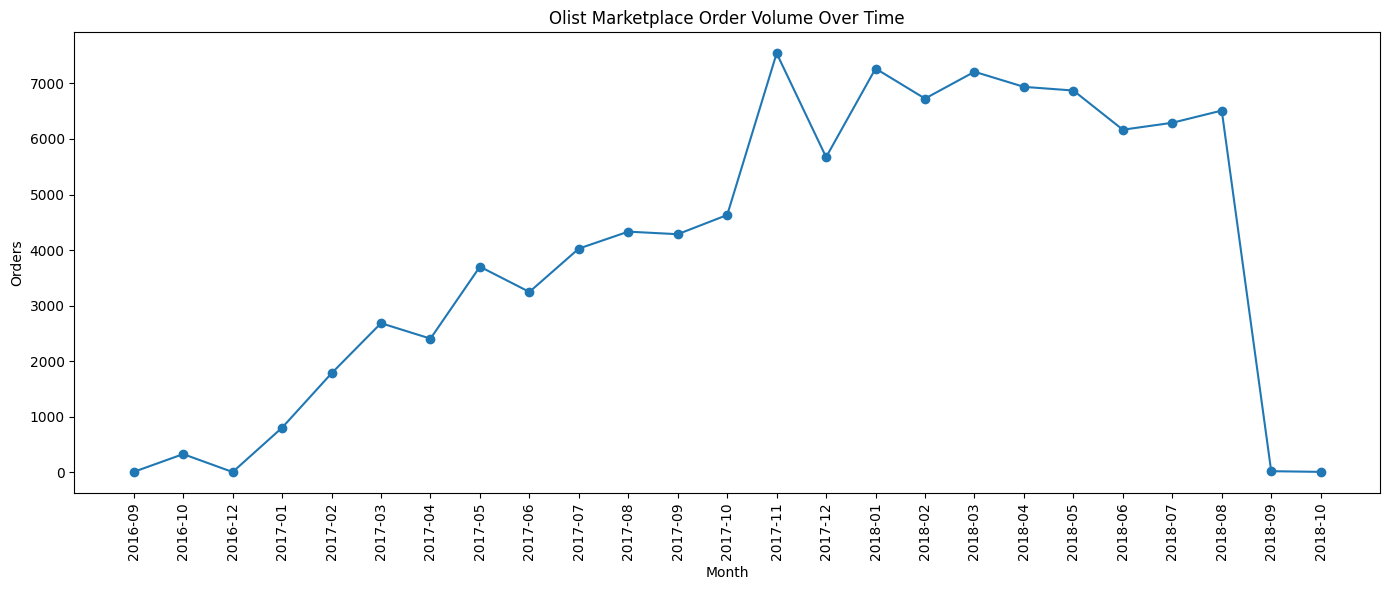

In [65]:
import matplotlib.pyplot as plt

trend = (
    master.assign(
        order_month=master['order_purchase_timestamp'].dt.to_period('M').astype(str)
    )
    .groupby('order_month')
    .agg(
        orders=('order_id', 'nunique'),
        revenue=('total_price', 'sum')
    )
    .reset_index()
)

fig, ax1 = plt.subplots(figsize=(14,6))

ax1.plot(trend['order_month'], trend['orders'], marker='o')
ax1.set_xlabel('Month')
ax1.set_ylabel('Orders')
ax1.tick_params(axis='x', rotation=90)

plt.title('Olist Marketplace Order Volume Over Time')
plt.tight_layout()
plt.show()

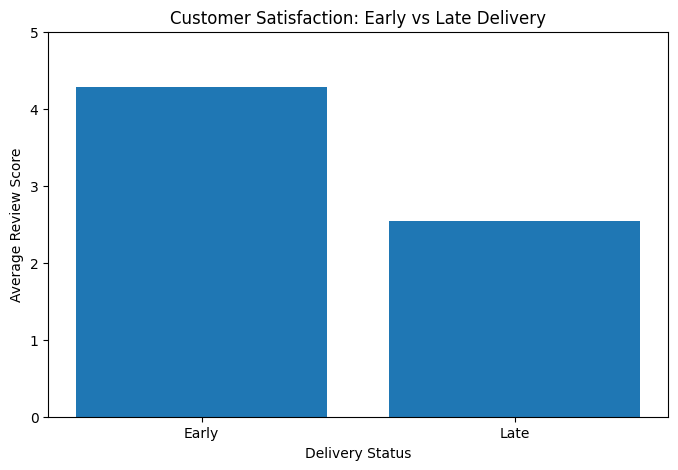

In [66]:
delivery_chart = (
    master[master['review_score'].notna()]
    .groupby('delivery_status')
    .agg(
        average_review=('review_score', 'mean'),
        orders=('order_id', 'nunique')
    )
    .reset_index()
)

plt.figure(figsize=(8,5))
plt.bar(
    delivery_chart['delivery_status'],
    delivery_chart['average_review']
)

plt.ylabel('Average Review Score')
plt.xlabel('Delivery Status')
plt.title('Customer Satisfaction: Early vs Late Delivery')
plt.ylim(0,5)

plt.show()

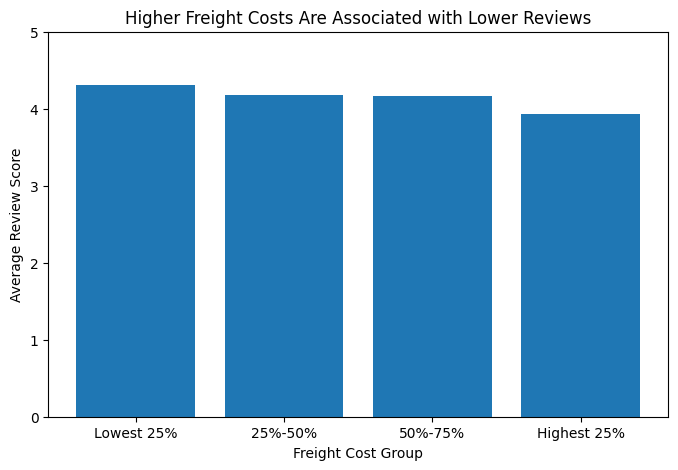

In [67]:
plt.figure(figsize=(8,5))

plt.bar(
    freight_summary['freight_group'],
    freight_summary['average_review']
)

plt.ylabel('Average Review Score')
plt.xlabel('Freight Cost Group')
plt.title('Higher Freight Costs Are Associated with Lower Reviews')
plt.ylim(0,5)

plt.show()

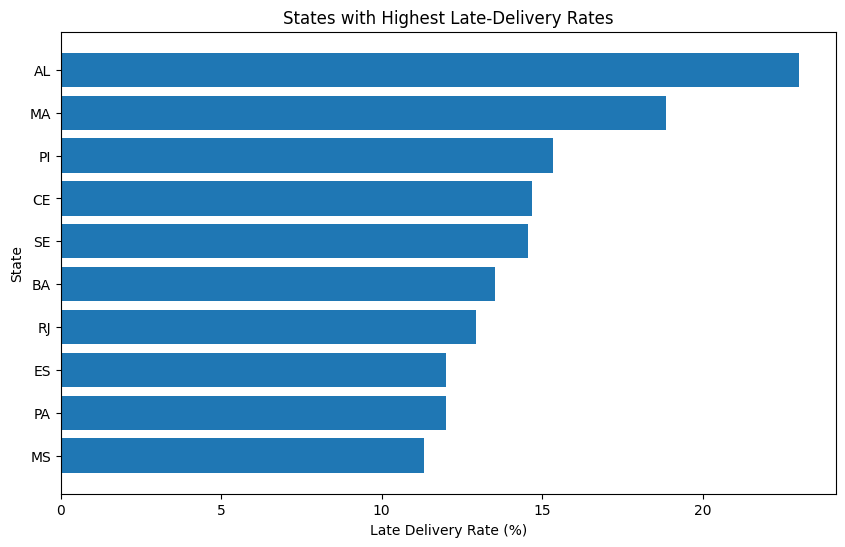

In [68]:
state_chart = (
    master[master['review_score'].notna()]
    .groupby('customer_state')
    .agg(
        orders=('order_id', 'nunique'),
        late_rate=('delivery_status',
                   lambda x: (x == 'Late').mean() * 100)
    )
    .query('orders >= 300')
    .sort_values('late_rate', ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(10,6))

plt.barh(
    state_chart['customer_state'],
    state_chart['late_rate']
)

plt.xlabel('Late Delivery Rate (%)')
plt.ylabel('State')
plt.title('States with Highest Late-Delivery Rates')
plt.gca().invert_yaxis()

plt.show()

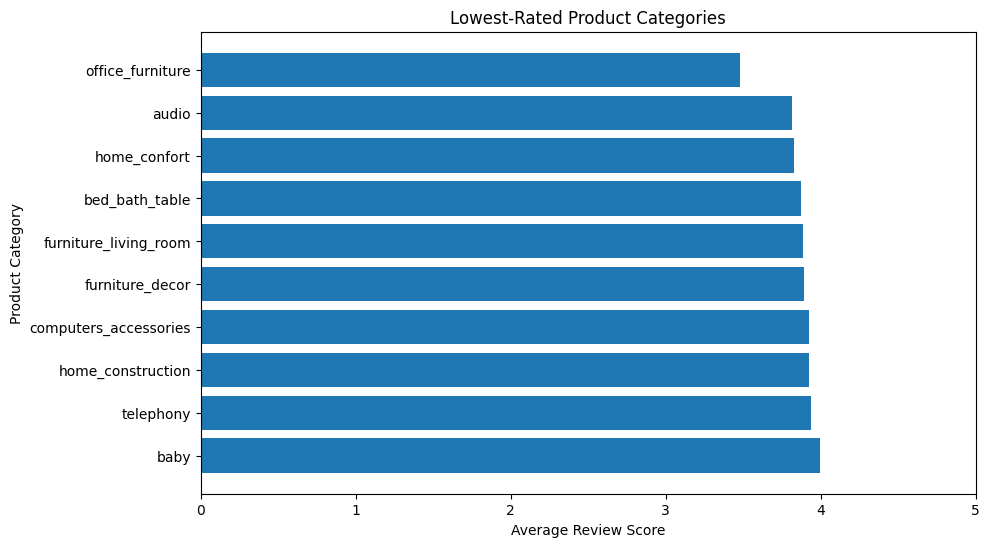

In [69]:
category_chart = (
    category_items
    .groupby('product_category_name_english')
    .agg(
        orders=('order_id', 'nunique'),
        average_price=('price', 'mean'),
        average_freight=('freight_value', 'mean')
    )
    .reset_index()
)

category_review = (
    master.merge(
        items[['order_id', 'product_id']],
        on='order_id',
        how='left'
    )
    .merge(
        products[['product_id', 'product_category_name']],
        on='product_id',
        how='left'
    )
    .merge(
        translation,
        on='product_category_name',
        how='left'
    )
    .groupby('product_category_name_english')
    .agg(
        orders=('order_id', 'nunique'),
        average_review=('review_score', 'mean')
    )
    .query('orders >= 300')
    .sort_values('average_review')
    .head(10)
    .reset_index()
)

plt.figure(figsize=(10,6))

plt.barh(
    category_review['product_category_name_english'],
    category_review['average_review']
)

plt.xlabel('Average Review Score')
plt.ylabel('Product Category')
plt.title('Lowest-Rated Product Categories')
plt.xlim(0,5)
plt.gca().invert_yaxis()

plt.show()

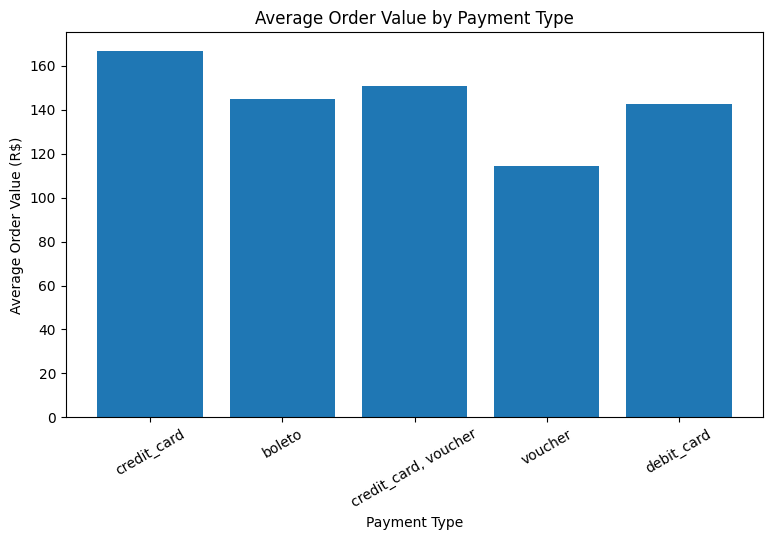

In [70]:
payment_plot = payment_summary[
    payment_summary['orders'] >= 100
].copy()

plt.figure(figsize=(9,5))

plt.bar(
    payment_plot['payment_type'],
    payment_plot['average_order_value']
)

plt.ylabel('Average Order Value (R$)')
plt.xlabel('Payment Type')
plt.title('Average Order Value by Payment Type')
plt.xticks(rotation=30)

plt.show()

In [71]:
# ============================================
# FINAL KPI SUMMARY
# ============================================

print("FINAL KPI SUMMARY")
print("=" * 60)

print(f"Total Orders: {master['order_id'].nunique():,}")
print(f"Total Revenue: ₹{master['total_price'].sum():,.2f}")
print(f"Average Order Value: ₹{master['total_price'].mean():,.2f}")
print(f"Average Review Score: {master['review_score'].mean():.2f}")

delivered = master[master['order_status'] == 'delivered']

late_rate = (delivered['delivery_status'] == 'Late').mean() * 100

print(f"Late Delivery Rate: {late_rate:.2f}%")
print(f"Total Customers: {master['customer_id'].nunique():,}")
print(f"Total Sellers: {sellers['seller_id'].nunique():,}")

print("\nTOP CATEGORY BY REVENUE")
print("=" * 60)

category_revenue = (
    category_items
    .groupby('product_category_name_english')['price']
    .sum()
    .sort_values(ascending=False)
)

print(category_revenue.head(5))

FINAL KPI SUMMARY
Total Orders: 99,441
Total Revenue: ₹13,591,643.70
Average Order Value: ₹137.75
Average Review Score: 4.07
Late Delivery Rate: 8.11%
Total Customers: 99,441
Total Sellers: 3,095

TOP CATEGORY BY REVENUE
product_category_name_english
health_beauty            1258681.34
watches_gifts            1205005.68
bed_bath_table           1036988.68
sports_leisure            988048.97
computers_accessories     911954.32
Name: price, dtype: float64


In [72]:
# ============================================
# EXECUTIVE BUSINESS INSIGHTS
# ============================================

insights = {
    "Total Orders": len(master),
    "Total Revenue": master["total_price"].sum(),
    "Average Order Value": master["total_price"].mean(),
    "Average Review Score": master["review_score"].mean(),
    "Late Delivery Rate": (master["delivery_status"] == "Late").mean() * 100,
    "Total Customers": master["customer_id"].nunique(),
    "Total Sellers": items["seller_id"].nunique()
}

print("EXECUTIVE BUSINESS INSIGHTS")
print("=" * 60)

for key, value in insights.items():
    if "Rate" in key:
        print(f"{key}: {value:.2f}%")
    elif "Revenue" in key or "Value" in key:
        print(f"{key}: ₹{value:,.2f}")
    else:
        print(f"{key}: {value:,.2f}" if isinstance(value, float) else f"{key}: {value:,}")

EXECUTIVE BUSINESS INSIGHTS
Total Orders: 99,441
Total Revenue: ₹13,591,643.70
Average Order Value: ₹137.75
Average Review Score: 4.07
Late Delivery Rate: 7.87%
Total Customers: 99,441
Total Sellers: 3,095


In [73]:
# ============================================
# FINAL BUSINESS RECOMMENDATIONS
# ============================================

print("FINAL BUSINESS RECOMMENDATIONS")
print("=" * 70)

print("\n1. IMPROVE DELIVERY PERFORMANCE")
print("-" * 70)
print("Late deliveries have a strong negative relationship with customer reviews.")
print("Early deliveries: 4.28 average review")
print("Late deliveries: 2.55 average review")
print("Recommendation: Focus on reducing delivery delays, especially in high-late-rate states.")

print("\n2. INVESTIGATE HIGH-FREIGHT ORDERS")
print("-" * 70)
print("Highest freight group:")
print("Average freight: 45.44")
print("Late-delivery rate: 9.25%")
print("Recommendation: Review shipping routes, logistics partners and freight pricing.")

print("\n3. FOCUS ON HIGH-REVENUE CATEGORIES")
print("-" * 70)
print("Top revenue categories:")
print("Health & Beauty: ₹1,258,681.34")
print("Watches & Gifts: ₹1,205,005.68")
print("Bed/Bath/Table: ₹1,036,988.68")
print("Recommendation: Maintain inventory and marketing investment in these categories.")

print("\n4. IMPROVE LOW-RATED CATEGORIES")
print("-" * 70)
print("Lowest-rated category:")
print("Office Furniture: 3.48 average review")
print("Recommendation: Investigate product quality, seller performance and delivery issues.")

print("\n5. MONITOR LOW-PERFORMING STATES")
print("-" * 70)
print("Highest late-delivery-rate states include:")
print("AL: 23.93%")
print("MA: 19.67%")
print("PI: 15.97%")
print("CE: 15.32%")
print("Recommendation: Investigate regional logistics and delivery infrastructure.")

print("\n6. MONITOR SELLER QUALITY")
print("-" * 70)
print("Some sellers have substantially lower customer ratings.")
print("Recommendation: Create seller-performance monitoring using review scores,")
print("late-delivery rates and revenue together.")

FINAL BUSINESS RECOMMENDATIONS

1. IMPROVE DELIVERY PERFORMANCE
----------------------------------------------------------------------
Late deliveries have a strong negative relationship with customer reviews.
Early deliveries: 4.28 average review
Late deliveries: 2.55 average review
Recommendation: Focus on reducing delivery delays, especially in high-late-rate states.

2. INVESTIGATE HIGH-FREIGHT ORDERS
----------------------------------------------------------------------
Highest freight group:
Average freight: 45.44
Late-delivery rate: 9.25%
Recommendation: Review shipping routes, logistics partners and freight pricing.

3. FOCUS ON HIGH-REVENUE CATEGORIES
----------------------------------------------------------------------
Top revenue categories:
Health & Beauty: ₹1,258,681.34
Watches & Gifts: ₹1,205,005.68
Bed/Bath/Table: ₹1,036,988.68
Recommendation: Maintain inventory and marketing investment in these categories.

4. IMPROVE LOW-RATED CATEGORIES
------------------------------

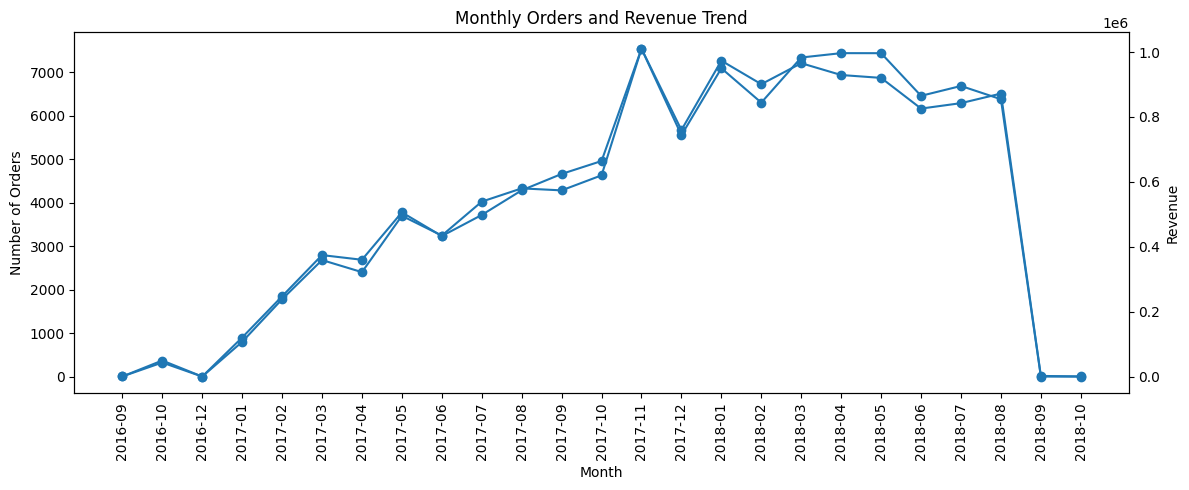

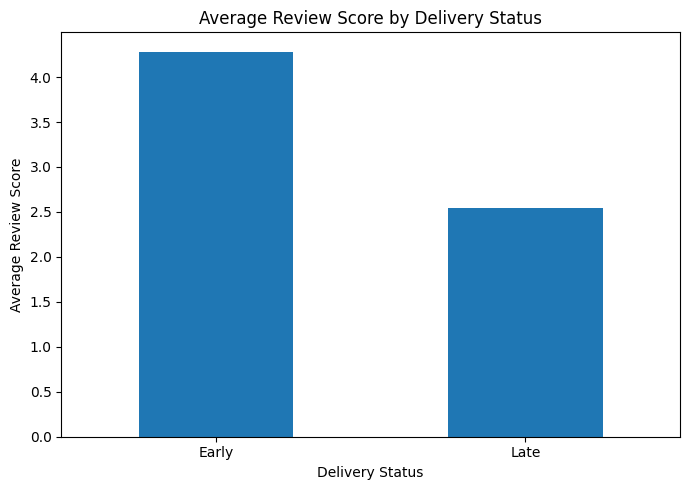

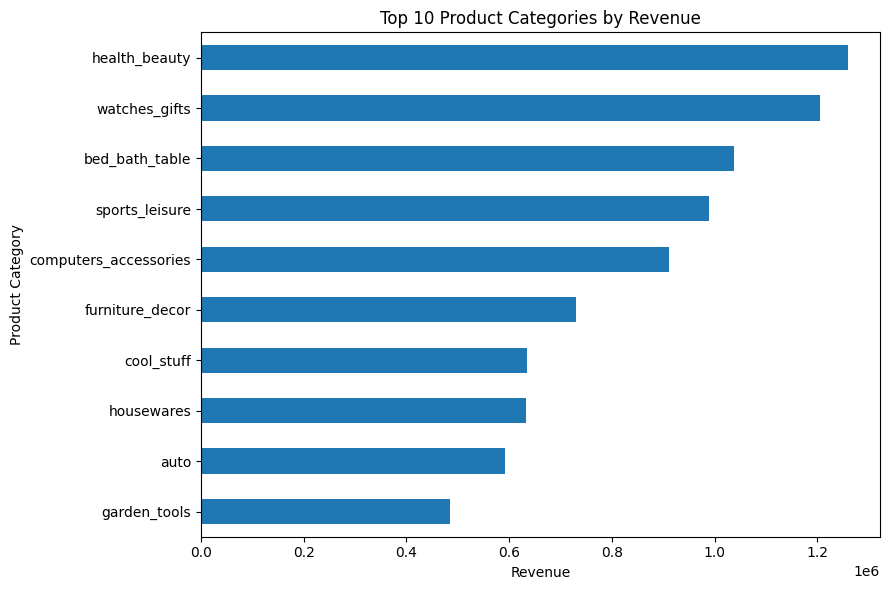

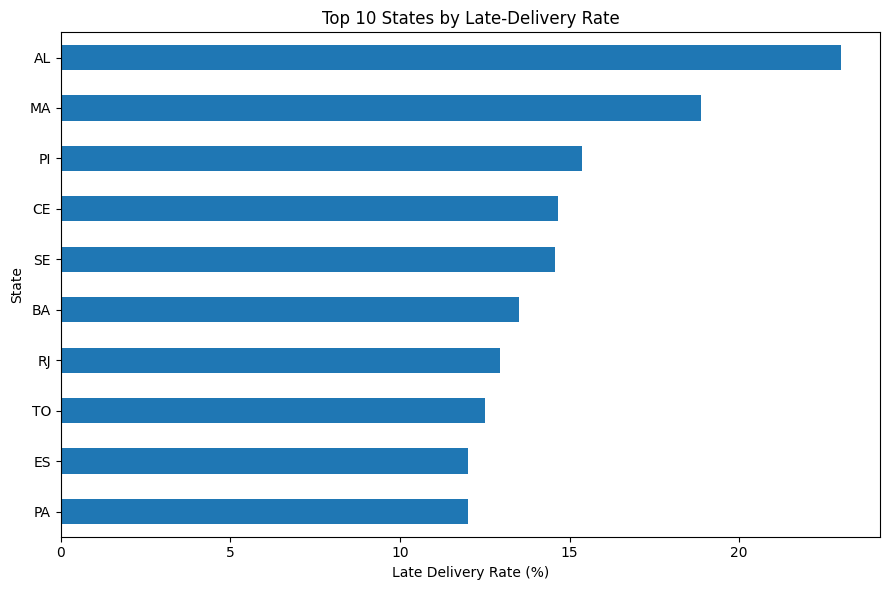

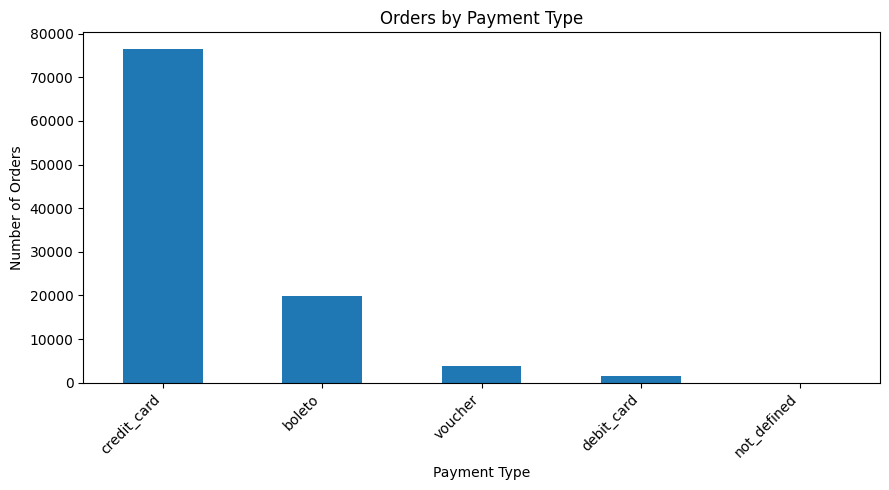


PAYMENT PERFORMANCE
              orders  average_payment
payment_type                         
credit_card    76505       163.319021
boleto         19784       145.034435
voucher         3866        65.703354
debit_card      1528       142.570170
not_defined        3         0.000000


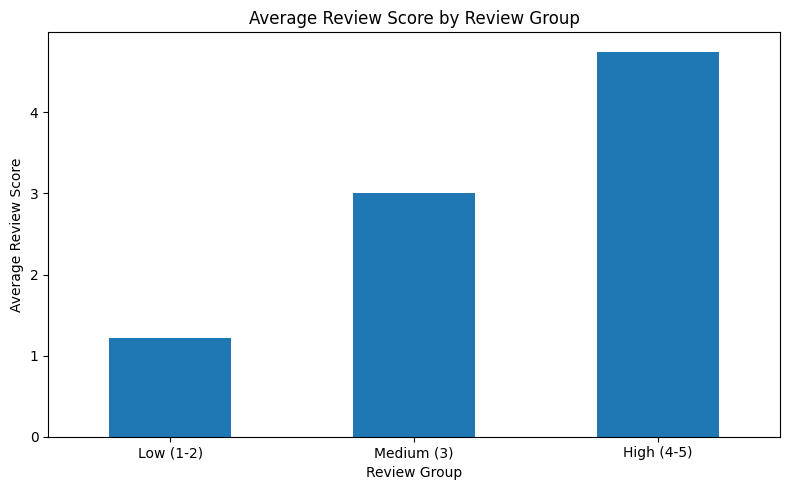


REVIEW GROUP PERFORMANCE
              orders  average_review  late_rate
review_group                                   
Low (1-2)      14963        1.214596  28.537058
Medium (3)      8241        3.000000  10.751122
High (4-5)     76173        4.749240   3.494677

FINAL DASHBOARD CHARTS CREATED SUCCESSFULLY!


In [77]:
# ============================================
# STEP 4 — FINAL DASHBOARD CHARTS
# ============================================

import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------
# 1. MONTHLY ORDERS & REVENUE
# --------------------------------------------

master['order_purchase_timestamp'] = pd.to_datetime(
    master['order_purchase_timestamp']
)

monthly = (
    master.groupby(
        master['order_purchase_timestamp'].dt.to_period('M')
    )
    .agg(
        orders=('order_id', 'count'),
        revenue=('total_price', 'sum')
    )
    .reset_index()
)

monthly['order_month'] = monthly['order_purchase_timestamp'].astype(str)

fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(
    monthly['order_month'],
    monthly['orders'],
    marker='o'
)

ax1.set_xlabel('Month')
ax1.set_ylabel('Number of Orders')
ax1.tick_params(axis='x', rotation=90)

ax2 = ax1.twinx()

ax2.plot(
    monthly['order_month'],
    monthly['revenue'],
    marker='o'
)

ax2.set_ylabel('Revenue')

plt.title('Monthly Orders and Revenue Trend')
plt.tight_layout()
plt.show()


# --------------------------------------------
# 2. DELIVERY STATUS VS REVIEW SCORE
# --------------------------------------------

delivery_review = (
    master.groupby('delivery_status')['review_score']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(7, 5))

delivery_review.plot(
    kind='bar'
)

plt.title('Average Review Score by Delivery Status')
plt.xlabel('Delivery Status')
plt.ylabel('Average Review Score')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## --------------------------------------------
# 3. TOP 10 CATEGORIES BY REVENUE
# --------------------------------------------

# Use the category-item dataset you created earlier
category_revenue = (
    category_items.groupby('product_category_name_english')['price']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .sort_values()
)

plt.figure(figsize=(9, 6))

category_revenue.plot(kind='barh')

plt.title('Top 10 Product Categories by Revenue')
plt.xlabel('Revenue')
plt.ylabel('Product Category')

plt.tight_layout()
plt.show()


# --------------------------------------------
# 4. TOP STATES BY LATE DELIVERY RATE
# --------------------------------------------

state_late = (
    master.groupby('customer_state')
    .agg(
        orders=('order_id', 'count'),
        late_rate=('delivery_status',
                   lambda x: (x == 'Late').mean() * 100)
    )
)

# Ignore states with very few orders
state_late = (
    state_late[state_late['orders'] >= 100]
    .sort_values('late_rate', ascending=False)
    .head(10)
    .sort_values('late_rate')
)

plt.figure(figsize=(9, 6))

state_late['late_rate'].plot(
    kind='barh'
)

plt.title('Top 10 States by Late-Delivery Rate')
plt.xlabel('Late Delivery Rate (%)')
plt.ylabel('State')
plt.tight_layout()
plt.show()


# --------------------------------------------
# 5. PAYMENT TYPE PERFORMANCE
# --------------------------------------------

payment_performance = (
    payments.groupby('payment_type')
    .agg(
        orders=('order_id', 'nunique'),
        average_payment=('payment_value', 'mean')
    )
    .sort_values('orders', ascending=False)
)

plt.figure(figsize=(9, 5))

payment_performance['orders'].plot(kind='bar')

plt.title('Orders by Payment Type')
plt.xlabel('Payment Type')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

print("\nPAYMENT PERFORMANCE")
print(payment_performance)

# --------------------------------------------
# 6. REVIEW GROUP PERFORMANCE
# --------------------------------------------

# Create review groups from review scores
master['review_group'] = master['review_score'].apply(
    lambda x: 'Low (1-2)' if x <= 2
    else ('Medium (3)' if x == 3
          else ('High (4-5)' if x >= 4 else 'Unknown'))
)

# Remove missing/unknown review scores
review_data = master[master['review_group'] != 'Unknown'].copy()

review_group = (
    review_data.groupby('review_group')
    .agg(
        orders=('order_id', 'count'),
        average_review=('review_score', 'mean'),
        late_rate=('delivery_status',
                   lambda x: (x == 'Late').mean() * 100)
    )
)

# Put groups in logical order
group_order = ['Low (1-2)', 'Medium (3)', 'High (4-5)']
review_group = review_group.reindex(group_order)

plt.figure(figsize=(8, 5))

review_group['average_review'].plot(kind='bar')

plt.title('Average Review Score by Review Group')
plt.xlabel('Review Group')
plt.ylabel('Average Review Score')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

print("\nREVIEW GROUP PERFORMANCE")
print("=" * 60)
print(review_group)

print("\nFINAL DASHBOARD CHARTS CREATED SUCCESSFULLY!")

In [78]:
# ============================================
# STEP 5 — FINAL PROJECT CONCLUSION
# ============================================

print("FINAL PROJECT EXECUTIVE SUMMARY")
print("=" * 70)

print("\nBUSINESS OVERVIEW")
print("-" * 70)
print("The marketplace processed 99,441 orders with total revenue of ₹13.59 million.")
print("The average order value was ₹137.75 and the overall average review score was 4.07.")

print("\nCUSTOMER EXPERIENCE")
print("-" * 70)
print("Delivery performance is strongly associated with customer satisfaction.")
print("High-rated orders (4-5) had a 3.49% late-delivery rate.")
print("Low-rated orders (1-2) had a 28.54% late-delivery rate.")
print("This indicates that reducing delivery delays should be a major business priority.")

print("\nREVENUE OPPORTUNITIES")
print("-" * 70)
print("Health & Beauty generated the highest category revenue at ₹1.26 million.")
print("Watches & Gifts generated approximately ₹1.21 million.")
print("Bed/Bath/Table generated approximately ₹1.04 million.")

print("\nOPERATIONAL RISKS")
print("-" * 70)
print("High-freight orders experienced a higher late-delivery rate.")
print("Several states also showed significantly higher late-delivery rates.")
print("Some sellers and categories had substantially lower customer ratings.")

print("\nFINAL RECOMMENDATIONS")
print("-" * 70)
print("1. Reduce late deliveries through better logistics and regional planning.")
print("2. Investigate high-freight routes and shipping costs.")
print("3. Continue supporting high-revenue product categories.")
print("4. Improve low-rated categories and underperforming sellers.")
print("5. Monitor state-level delivery performance.")
print("6. Track customer reviews as an important marketplace KPI.")

print("\nCONCLUSION")
print("-" * 70)
print("The analysis shows that marketplace growth is not only driven by sales volume.")
print("Delivery reliability, freight cost, seller performance and customer satisfaction")
print("are closely connected to overall marketplace performance.")
print("Improving these operational areas can support stronger customer satisfaction")
print("and sustainable marketplace growth.")

print("\n" + "=" * 70)
print("PROJECT ANALYSIS COMPLETED SUCCESSFULLY!")
print("=" * 70)

FINAL PROJECT EXECUTIVE SUMMARY

BUSINESS OVERVIEW
----------------------------------------------------------------------
The marketplace processed 99,441 orders with total revenue of ₹13.59 million.
The average order value was ₹137.75 and the overall average review score was 4.07.

CUSTOMER EXPERIENCE
----------------------------------------------------------------------
Delivery performance is strongly associated with customer satisfaction.
High-rated orders (4-5) had a 3.49% late-delivery rate.
Low-rated orders (1-2) had a 28.54% late-delivery rate.
This indicates that reducing delivery delays should be a major business priority.

REVENUE OPPORTUNITIES
----------------------------------------------------------------------
Health & Beauty generated the highest category revenue at ₹1.26 million.
Watches & Gifts generated approximately ₹1.21 million.
Bed/Bath/Table generated approximately ₹1.04 million.

OPERATIONAL RISKS
----------------------------------------------------------------